Boundary Flux Jacobian v2

Updates in v2
1. accounted for non-frozen boundary nodes
- use exact formulation for slip wall boundary flux jacobian

2. allow multiple eps inside the boundary flux jacobian function
- ghost_state_jacobian (dUg/dUi) --> use eps = e-7
- viscous_flux_jacobian --> use eps = e-8

Function 
- ghost_state
- riemann_invariant_bc --> to get ghost state for riemann invariant BC
- boundary_flux_jacobian (by finite difference)

Added function
- wall_flux_jacobian_3d --> to get exact slip wall flux jacobian

Boundary Conditions to implement
- slip wall/ symmetric BC
- noslip adiabatic wall
- riemann invariant (subsonic inflow and outflow, supersonic inflow and outflow

In [8]:
import numpy as np
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # required: JAX defaults to float32

import matplotlib.pyplot as plt

In [9]:
# REQUIRED FUNCTIONS for assembly_global_flux_jacobian_fd v2
# with the consideration of non-frozen ghost cell for boundary flux jacobian of slip wall and riemann invariant bcs

# inviscid flux jacobian

def compute_dFdU(U, normal, gamma=1.4):
    """
    Compute the inviscid flux Jacobian matrix for 3D Euler equations.

    Based on equation (A.47) from Chung's Computationa Fluid Dynamics.
    Parameters
    ----------
    U : array-like, shape (5,)
        Conservative variable vector [rho, rho*u, rho*v, rho*w, rho*E]
        where:
        - rho: density
        - u, v, w: velocity components
        - E: specific total energy

    normal : array-like, shape (3,)
        Unit normal vector [n_x, n_y, n_z]

    gamma : float, optional
        Specific heat ratio (default: 1.4 for air)

    Returns
    -------
    dF_dU : ndarray, shape (5, 5)
        Flux Jacobian matrix
    """

    # Extract conservative variables
    rho = U[0]
    rho_u = U[1]
    rho_v = U[2]
    rho_w = U[3]
    rho_E = U[4]

    # Extract normal vector components
    n_x = normal[0]
    n_y = normal[1]
    n_z = normal[2]

    # Compute primitive variables
    u = rho_u / rho
    v = rho_v / rho
    w = rho_w / rho
    E = rho_E / rho

    # Compute auxiliary quantities (from A.48)
    # phi = 0.5 * (gamma - 1) * (u^2 + v^2 + w^2)
    phi = 0.5 * (gamma - 1.0) * (u**2 + v**2 + w**2)

    # V = n_x*u + n_y*v + n_z*w (normal component of velocity)
    V = n_x * u + n_y * v + n_z * w

    # a1 = gamma*E - phi
    a1 = gamma * E - phi

    # a2 = gamma - 1
    a2 = gamma - 1.0

    # a3 = gamma - 2
    a3 = gamma - 2.0

    # Initialize Jacobian matrix
    dF_dU = np.zeros((5, 5))

    # Row 1: d(rho*V)/d(U)
    dF_dU[0, 0] = 0
    dF_dU[0, 1] = n_x
    dF_dU[0, 2] = n_y
    dF_dU[0, 3] = n_z
    dF_dU[0, 4] = 0.0

    # Row 2: d(rho*u*V)/d(U)
    dF_dU[1, 0] = n_x * phi - u * V
    dF_dU[1, 1] = V - a3 * n_x * u
    dF_dU[1, 2] = n_y * u - a2 * n_x *v
    dF_dU[1, 3] = n_z * u - a2 * n_x * w
    dF_dU[1, 4] = a2 * n_x

    # Row 3: d(rho*v*V)/d(U)
    dF_dU[2, 0] = n_y * phi - v * V
    dF_dU[2, 1] = n_x * v - a2 * n_y *u
    dF_dU[2, 2] = V - a3 * n_y * v
    dF_dU[2, 3] = n_z * v - a2 * n_y * w
    dF_dU[2, 4] = a2 * n_y

    # Row 4: d(rho*w*V)/d(U)
    dF_dU[3, 0] = n_z * phi - w * V
    dF_dU[3, 1] = n_x * w - a2 * n_z *u
    dF_dU[3, 2] = n_y * w - a2 * n_z *v
    dF_dU[3, 3] =  V - a3 * n_z * w
    dF_dU[3, 4] = a2 * n_z

    # Row 5: d(rho*H*V)/d(U)
    dF_dU[4, 0] = V * (phi - a1)
    dF_dU[4, 1] = a1 * n_x - a2 * u * V
    dF_dU[4, 2] = a1 * n_y - a2 * v * V
    dF_dU[4, 3] = a1 * n_z - a2 * w * V
    dF_dU[4, 4] = gamma * V

    return dF_dU

def absolute_normal_jacobian(U, n, gamma=1.4):
    """
    Compute the absolute value of the normal Jacobian |A_n| for the
    3D Euler equations without tangent-vector ambiguity (eqs. 3.6.16–3.6.26).

    Parameters
    ----------
    U : array-like, shape (5,)
        Conservative variables [rho, rho*u, rho*v, rho*w, rho*E].
    n : array-like, shape (3,)
        Face normal vector (need not be unit length; normalised internally).
    gamma : float
        Ratio of specific heats (default 1.4).

    Returns
    -------
    abs_An : ndarray, shape (5, 5)
        Absolute normal Jacobian matrix.
    """
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float)
    n = n / np.linalg.norm(n)          # unit normal

    # ------------------------------------------------------------------ #
    # Primitive / thermodynamic quantities
    # ------------------------------------------------------------------ #
    rho  = U[0]
    vel  = U[1:4] / rho                # velocity vector  v = (u, v, w)
    E    = U[4]   / rho                # total energy per unit mass
    q2   = np.dot(vel, vel)            # |v|^2
    p    = (gamma - 1.0) * rho * (E - 0.5 * q2)
    c    = np.sqrt(gamma * p / rho)    # speed of sound
    H    = E + p / rho                 # total enthalpy per unit mass
    qn   = np.dot(vel, n)              # normal velocity  q_n
    M2   = q2 / c**2                   # Mach^2
    Mn   = qn / c                      # normal Mach number  M_n
    g1   = gamma - 1.0

    # ------------------------------------------------------------------ #
    # Contribution from eigenvalue qn  (eq. 3.6.24)
    # |qn| * (r2*l2' + r4*l4' + r5*l5')
    # ------------------------------------------------------------------ #
    mid = np.zeros((5, 5))

    # row 0
    mid[0, 0]   =  1.0 - 0.5 * g1 * M2
    mid[0, 1:4] =  (g1 / c**2) * vel
    mid[0, 4]   = -(g1 / c**2)

    # rows 1-3
    mid[1:4, 0]   = -0.5 * g1 * M2 * vel + qn * n
    mid[1:4, 1:4] =  (g1 / c**2) * np.outer(vel, vel) + np.eye(3) - np.outer(n, n)
    mid[1:4, 4]   = -(g1 / c**2) * vel

    # row 4
    mid[4, 0]   =  qn**2 - 0.5 * q2 * (1.0 + 0.5 * g1 * M2)
    mid[4, 1:4] =  (1.0 + 0.5 * g1 * M2) * vel - qn * n
    mid[4, 4]   = -0.5 * g1 * M2

    # ------------------------------------------------------------------ #
    # Contribution from eigenvalue (qn - c)  (eq. 3.6.25)
    # r1 * l1'
    # ------------------------------------------------------------------ #
    l1 = np.empty(5)
    l1[0]   =  0.25 * g1 * M2 + 0.5 * Mn
    l1[1:4] = -(g1 / (2.0 * c**2)) * vel - n / (2.0 * c)
    l1[4]   =  g1 / (2.0 * c**2)

    r1 = np.empty(5)
    r1[0]   =  1.0
    r1[1:4] =  vel - c * n
    r1[4]   =  H - qn * c

    A1 = np.outer(r1, l1)

    # ------------------------------------------------------------------ #
    # Contribution from eigenvalue (qn + c)  (eq. 3.6.26)
    # r3 * l3'
    # ------------------------------------------------------------------ #
    l3 = np.empty(5)
    l3[0]   =  0.25 * g1 * M2 - 0.5 * Mn
    l3[1:4] = -(g1 / (2.0 * c**2)) * vel + n / (2.0 * c)
    l3[4]   =  g1 / (2.0 * c**2)

    r3 = np.empty(5)
    r3[0]   =  1.0
    r3[1:4] =  vel + c * n
    r3[4]   =  H + qn * c

    A3 = np.outer(r3, l3)

    # ------------------------------------------------------------------ #
    # Assemble  |A_n| = |qn-c|*A1 + |qn|*mid + |qn+c|*A3   (eq. 3.6.19)
    # ------------------------------------------------------------------ #
    abs_An = abs(qn - c) * A1 + abs(qn) * mid + abs(qn + c) * A3

    return abs_An

def roe_average(UL, UR, gamma=1.4):
    """
    Compute the Roe-averaged conservative variable vector for the 3D Euler equations.
 
    Parameters
    ----------
    UL, UR : array-like, shape (5,)
        Left/right conservative vectors [rho, rho*u, rho*v, rho*w, rho*E].
    gamma : float
        Ratio of specific heats (default 1.4).
 
    Returns
    -------
    U_roe : ndarray, shape (5,)
        Roe-averaged conservative variable vector.
    """
    UL = np.asarray(UL, dtype=float)
    UR = np.asarray(UR, dtype=float)
 
    rhoL, rhoR = UL[0], UR[0]
    velL = UL[1:4] / rhoL
    velR = UR[1:4] / rhoR
    EL   = UL[4] / rhoL
    ER   = UR[4] / rhoR
 
    pL = (gamma - 1.0) * rhoL * (EL - 0.5 * np.dot(velL, velL))
    pR = (gamma - 1.0) * rhoR * (ER - 0.5 * np.dot(velR, velR))
    HL = EL + pL / rhoL    # total enthalpy per unit mass
    HR = ER + pR / rhoR
 
    wL = np.sqrt(rhoL)     # Roe weight for left state
    wR = np.sqrt(rhoR)     # Roe weight for right state
    ws = wL + wR
 
    rho_roe = wL * wR                          # = sqrt(rhoL * rhoR)
    vel_roe = (wL * velL + wR * velR) / ws
    H_roe   = (wL * HL   + wR * HR)   / ws
 
    # Recover E from H:  H = gamma*E - (gamma-1)/2 * |v|^2
    q2_roe = np.dot(vel_roe, vel_roe)
    E_roe  = (H_roe + (gamma - 1.0) * 0.5 * q2_roe) / gamma
 
    U_roe = np.empty(5)
    U_roe[0]   = rho_roe
    U_roe[1:4] = rho_roe * vel_roe
    U_roe[4]   = rho_roe * E_roe
    
    return U_roe

def inviscid_flux_jacobians(U_i, U_j, n,gamma=1.4):
    """
    Compute the normal inviscid flux Jacobian blocks at a cell face between
    cell i (left/owner) and cell j (right/neighbor).

    Parameters
    ----------
    U_i, U_j : array_like, shape (5,)
        Conservative variables [rho, rho*u, rho*v, rho*w, rho*E] of the
        two cells sharing the face.
    n : array_like, shape (3,)
        Unit normal vector [nx, ny, nz] of the face, pointing from i to j.
    gamma: float
        Ratio of specific heats
    Returns
    -------
    d(F)/d(U_i)  -- Inviscid Jacobian wrt the left-cell conservative state.
    d(F)/d(U_j)  -- Inviscid Jacobian wrt the right-cell conservative state.
    """

    U_roe = roe_average(U_i, U_j, gamma)
    abs_A_roe = absolute_normal_jacobian(U_roe, n, gamma=gamma)
    dFdUi = 0.5 * (compute_dFdU(U_i, n) + abs_A_roe)
    dFdUj = 0.5 * (compute_dFdU(U_j, n) - abs_A_roe)
    
    return dFdUi, dFdUj


# normal viscous flux jacobian

"""
3D Normal Viscous Flux Jacobian (interface between two control volumes)
========================================================================

Implements d(F_n^v)/dU_i  and  d(F_n^v)/dU_j, i.e. the Jacobian of the
normal (projected) viscous flux F_n^v with respect to the conservative
variables of the two cells (i = "left", j = "right") sharing a face,
following the construction:

        F_n^v = [0, -tau_nx, -tau_ny, -tau_nz, -tau_nn + q_n]^T      (eq. 4.12.5)

        d F_n^v / dU = (d F_n^v / dW) * (dW / dU)                    (eq. 4.12.15)

with W = [rho, u, v, w, p]^T.

Modeling choices (consistent with the reference derivation):
  * Interface (averaged) primitive states are the simple arithmetic
    mean of the two cells:           phi_avg = (phi_i + phi_j) / 2   (eq. 4.12.25)
  * The normal derivative of any quantity is the directional
    finite difference across the two cell centers:
            d(phi)/dn = (phi_j - phi_i) / ds                          (eq. 4.12.26)
  * Because only the normal derivative is available (no compact
    stencil for the tangential derivatives), the full gradient is
    approximated as  grad(phi) ~= (d phi/dn) * n   (i.e. only the
    derivative along n is retained -- the same simplification used
    to reduce tau_bar.n to a function of d()/dn only, eq. 4.12.12-14).
  * Viscosity follows Sutherland's law (eq. 4.4.4) and its dependence
    on rho and p (through T = p/(rho*R)) is differentiated exactly
    via the symbolic chain rule -- this reproduces eq. (4.12.20)-(4.12.24)
    without having to hand-transcribe each partial derivative.

The two Jacobian blocks (wrt U_i and wrt U_j) are exactly what an
implicit (e.g. Newton/line-implicit/LU-SGS) viscous-flux assembly
needs for the off-diagonal/diagonal contributions of a face.

Author: generated to accompany the "3D Normal Viscous Flux and Jacobian"
notes (section 4.12).
"""

# ----------------------------------------------------------------------
# Conservative -> primitive variables
# ----------------------------------------------------------------------
def cons_to_prim(U, gamma, R_gas):
    """
    U = [rho, rho*u, rho*v, rho*w, rho*E]
    returns rho, u, v, w, p, T  (numeric floats)
    """
    rho = U[0]
    u = U[1] / rho
    v = U[2] / rho
    w = U[3] / rho
    E = U[4] / rho
    p = (gamma - 1.0) * rho * (E - 0.5 * (u * u + v * v + w * w))
    T = p / (rho * R_gas)
    return rho, u, v, w, p, T


# ----------------------------------------------------------------------
# Sutherland's law (eq. 4.4.4), symbolic-friendly
# ----------------------------------------------------------------------
def sutherland_mu(T, mu0, T0, C):
    return mu0 * (T0 + C) / (T + C) * (T / T0) ** sp.Rational(3, 2)


# ----------------------------------------------------------------------
# dW/dU  (the right-hand matrix of eq. 4.12.15), evaluated at a given
# primitive state.  W = [rho, u, v, w, p]^T , U = [rho, rho u, rho v, rho w, rho E]^T
# ----------------------------------------------------------------------
def dWdU(rho, u, v, w, p, gamma):
    q2 = u * u + v * v + w * w
    M = np.array([
        [1.0,                 0.0,            0.0,            0.0,            0.0],
        [-u / rho,            1.0 / rho,       0.0,            0.0,            0.0],
        [-v / rho,            0.0,             1.0 / rho,      0.0,            0.0],
        [-w / rho,            0.0,             0.0,            1.0 / rho,      0.0],
        [0.5 * (gamma - 1.0) * q2, -(gamma - 1.0) * u, -(gamma - 1.0) * v, -(gamma - 1.0) * w, (gamma - 1.0)]
    ])
    return M


# ----------------------------------------------------------------------
# Symbolic construction of F_n^v as a function of the LEFT state
# (rho_L,u_L,v_L,w_L,p_L) and the RIGHT state (rho_R,u_R,v_R,w_R,p_R).
# Works for either state being symbolic; the other is plugged in as
# plain numbers.
# ----------------------------------------------------------------------
def _Fnv_symbolic(rho_L, u_L, v_L, w_L, p_L,
                   rho_R, u_R, v_R, w_R, p_R,
                   nx, ny, nz, ds,
                   gamma, R_gas, Pr, mu0, T0, Suth_C):

    T_L = p_L / (rho_L * R_gas)
    T_R = p_R / (rho_R * R_gas)

    # interface-averaged primitive state                       (eq. 4.12.25 style)
    rho_avg = (rho_L + rho_R) / 2
    u_avg   = (u_L   + u_R)   / 2
    v_avg   = (v_L   + v_R)   / 2
    w_avg   = (w_L   + w_R)   / 2
    T_avg   = (T_L   + T_R)   / 2

    mu_avg = sutherland_mu(T_avg, mu0, T0, Suth_C)             # mu(T_avg(rho,p)) -> exact chain rule via sympy

    # normal derivatives                                        (eq. 4.12.26)
    dudn = (u_R - u_L) / ds
    dvdn = (v_R - v_L) / ds
    dwdn = (w_R - w_L) / ds
    dTdn = (T_R - T_L) / ds

    # full gradient approximated by the normal derivative only:
    #   grad(phi) ~= (d phi/dn) * n   =>   d phi/dx_k = (d phi/dn) * n_k
    div = dudn * nx + dvdn * ny + dwdn * nz   # du/dx + dv/dy + dw/dz

    # Newtonian viscous stress tensor with Stokes' hypothesis      (eq. 4.12.16-19)
    tau_xx = mu_avg * (2 * dudn * nx - sp.Rational(2, 3) * div)
    tau_yy = mu_avg * (2 * dvdn * ny - sp.Rational(2, 3) * div)
    tau_zz = mu_avg * (2 * dwdn * nz - sp.Rational(2, 3) * div)
    tau_xy = mu_avg * (dudn * ny + dvdn * nx)
    tau_xz = mu_avg * (dudn * nz + dwdn * nx)
    tau_yz = mu_avg * (dvdn * nz + dwdn * ny)

    # projection along n                                          (eq. 4.12.6-4.12.9)
    tau_nx = tau_xx * nx + tau_xy * ny + tau_xz * nz
    tau_ny = tau_xy * nx + tau_yy * ny + tau_yz * nz
    tau_nz = tau_xz * nx + tau_yz * ny + tau_zz * nz
    tau_nn = tau_nx * u_avg + tau_ny * v_avg + tau_nz * w_avg

    # heat flux                                                    (eq. 4.12.11)
    kappa_avg = gamma * mu_avg / (Pr * (gamma - 1.0))
    q_n = -kappa_avg * dTdn

    F0 = sp.Integer(0)
    F1 = -tau_nx
    F2 = -tau_ny
    F3 = -tau_nz
    F4 = -tau_nn + q_n
    return sp.Matrix([F0, F1, F2, F3, F4])


# ----------------------------------------------------------------------
# Purely numeric evaluation of F_n^v(U_i, U_j, n, ds)  -- the discretized
# normal viscous flux function itself (no differentiation). This is the
# "flux(U)" used by the finite-difference Jacobian below, and it uses
# exactly the same modeling choices as the analytic version above:
#   * interface state = arithmetic mean of the two cells   (eq. 4.12.25)
#   * spatial (normal) derivative = directional finite difference
#         d(phi)/dn = (phi_j - phi_i) / ds                  (eq. 4.12.26)
#     i.e. the ONLY spatial derivative information available is the
#     one-sided difference of the two cell-center values along the
#     line joining them; the gradient is then assumed aligned with n:
#         grad(phi) ~= (d phi/dn) * n
#     (tangential derivatives are not reconstructed/are neglected).
# ----------------------------------------------------------------------
def Fnv_numeric(U_i, U_j, n, ds,
                 gamma=1.4, R_gas=287.0, Pr=0.72,
                 mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    nx, ny, nz = n
    rho_L, u_L, v_L, w_L, p_L, T_L = cons_to_prim(U_i, gamma, R_gas)
    rho_R, u_R, v_R, w_R, p_R, T_R = cons_to_prim(U_j, gamma, R_gas)

    u_avg = (u_L + u_R) / 2
    v_avg = (v_L + v_R) / 2
    w_avg = (w_L + w_R) / 2
    T_avg = (T_L + T_R) / 2

    mu_avg = mu0 * (T0 + Suth_C) / (T_avg + Suth_C) * (T_avg / T0) ** 1.5

    dudn = (u_R - u_L) / ds
    dvdn = (v_R - v_L) / ds
    dwdn = (w_R - w_L) / ds
    dTdn = (T_R - T_L) / ds

    div = dudn * nx + dvdn * ny + dwdn * nz

    tau_xx = mu_avg * (2 * dudn * nx - (2.0 / 3.0) * div)
    tau_yy = mu_avg * (2 * dvdn * ny - (2.0 / 3.0) * div)
    tau_zz = mu_avg * (2 * dwdn * nz - (2.0 / 3.0) * div)
    tau_xy = mu_avg * (dudn * ny + dvdn * nx)
    tau_xz = mu_avg * (dudn * nz + dwdn * nx)
    tau_yz = mu_avg * (dvdn * nz + dwdn * ny)

    tau_nx = tau_xx * nx + tau_xy * ny + tau_xz * nz
    tau_ny = tau_xy * nx + tau_yy * ny + tau_yz * nz
    tau_nz = tau_xz * nx + tau_yz * ny + tau_zz * nz
    tau_nn = tau_nx * u_avg + tau_ny * v_avg + tau_nz * w_avg

    kappa_avg = gamma * mu_avg / (Pr * (gamma - 1.0))
    q_n = -kappa_avg * dTdn

    return np.array([0.0, -tau_nx, -tau_ny, -tau_nz, -tau_nn + q_n])


# ----------------------------------------------------------------------
# Finite-difference Jacobian (separate, independent function)
# ----------------------------------------------------------------------
def viscous_flux_jacobians_fd(U_i, U_j, n, ds, eps,
                               gamma=1.4, R_gas=287.0, Pr=0.72,
                               mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    """
    Finite-difference estimate of d(F_n^v)/d(U_i) and d(F_n^v)/d(U_j),
    using the SAME discretized flux function F_n^v(U_i, U_j, n, ds) as
    the analytic version (Fnv_numeric above), but differentiating it
    by brute-force one-sided (forward) perturbation instead of exact
    symbolic/analytic differentiation.

    How the spatial derivative is determined
    -----------------------------------------
    The flux function F_n^v(U_i, U_j, n, ds) itself still needs a
    normal *spatial* gradient at the face. That gradient is built
    exactly as in the analytic implementation:
        d(phi)/dn = (phi_j - phi_i) / ds          (one-sided/directional
                                                    finite difference
                                                    across the two cell
                                                    centers, eq. 4.12.26)
        grad(phi) ~= (d phi/dn) * n                (tangential gradient
                                                    components are not
                                                    available/neglected;
                                                    eq. 4.12.12-14)
    This part is NOT what "eps" controls -- it is fixed by the mesh
    geometry (n, ds) and is identical to the analytic Jacobian's
    assumption.

    How the JACOBIAN (d Flux/d U) is determined
    ---------------------------------------------
    "eps" is a separate, independent perturbation used only to
    differentiate the flux function with respect to the conservative
    variables, via a forward finite difference, one component at a
    time:

        d F_n^v / dU_i[:,k]  ~=  ( F_n^v(U_i + eps*e_k, U_j, n, ds)
                                    - F_n^v(U_i, U_j, n, ds) ) / eps

        d F_n^v / dU_j[:,k]  ~=  ( F_n^v(U_i, U_j + eps*e_k, n, ds)
                                    - F_n^v(U_i, U_j, n, ds) ) / eps

    where e_k is the k-th unit vector in conservative-variable space
    (rho, rho*u, rho*v, rho*w, rho*E) and eps is a small, user-specified
    ABSOLUTE perturbation added directly to that conservative variable
    (same units as U_i[k]/U_j[k]). This is a forward difference, first
    order accurate in eps, i.e. error ~ O(eps); the other cell's state,
    n and ds are held fixed during each perturbation.

    Note: the formula is divided by eps (the perturbation), NOT by U;
    dividing by U would not produce a derivative -- it is eps that
    plays the role of "delta U" in (Flux(U+eps) - Flux(U)) / eps.

    Parameters
    ----------
    U_i, U_j : array_like, shape (5,)
        Conservative variables of the two cells sharing the face.
    n : array_like, shape (3,)
        Unit normal vector [nx, ny, nz], pointing from i to j.
    ds : float
        Distance between the two cell centers.
    eps : float
        User-specified absolute perturbation applied to each
        conservative-variable component in turn.
    gamma, R_gas, Pr, mu0, T0, Suth_C :
        Same gas/transport parameters as the analytic version.

    Returns
    -------
    J_i_fd : ndarray, shape (5,5)
        Finite-difference estimate of d(F_n^v)/d(U_i).
    J_j_fd : ndarray, shape (5,5)
        Finite-difference estimate of d(F_n^v)/d(U_j).
    """
    U_i = np.asarray(U_i, dtype=float)
    U_j = np.asarray(U_j, dtype=float)

    F_base = Fnv_numeric(U_i, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)

    J_i_fd = np.zeros((5, 5))
    J_j_fd = np.zeros((5, 5))

    for k in range(5):
        # --- perturb cell i, component k ---
        U_i_pert = U_i.copy()
        U_i_pert[k] += eps
        F_pert_i = Fnv_numeric(U_i_pert, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
        J_i_fd[:, k] = (F_pert_i - F_base) / eps

        # --- perturb cell j, component k ---
        U_j_pert = U_j.copy()
        U_j_pert[k] += eps
        F_pert_j = Fnv_numeric(U_i, U_j_pert, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
        J_j_fd[:, k] = (F_pert_j - F_base) / eps

    return J_i_fd, J_j_fd



In [10]:
# boundary flux jacobian

def riemann_invariant_bc(U_int, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas=287.0):
    """
    Ghost cell state using Riemann invariant (characteristic) boundary condition.

    Incoming/outgoing waves are split based on sign of eigenvalues along n.
    Outgoing invariants are taken from the interior; incoming from prescribed state.

    Parameters
    ----------
    U_int  : array (5,)   interior conservative state [rho, rho*u, rho*v, rho*w, rho*E]
    n      : array (3,)   outward unit normal
    gamma  : float        ratio of specific heats
    u_b, v_b, w_b : float prescribed velocity components at boundary
    T_b    : float        prescribed temperature at boundary
    P_b    : float        prescribed pressure at boundary
    R_gas  : float        specific gas constant (default: air, 287 J/kg/K)

    Returns
    -------
    U_ghost : ndarray (5,)  ghost cell conservative variables
    info    : dict          diagnostic info (flow regime, Riemann invariants)
    """
    U_int = np.asarray(U_int, dtype=float)
    n     = np.asarray(n,     dtype=float)
    n     = n / np.linalg.norm(n)

    cv = R_gas / (gamma - 1.0)

    # ------------------------------------------------------------------ #
    # Interior primitives
    # ------------------------------------------------------------------ #
    rho_i = U_int[0]
    vel_i = U_int[1:4] / rho_i
    E_i   = U_int[4] / rho_i                         # specific total energy
    Vn_i  = np.dot(vel_i, n)                          # normal velocity (signed)
    Vt_i  = vel_i - Vn_i * n                          # tangential velocity vector
    p_i   = (gamma - 1.0) * rho_i * (E_i - 0.5 * np.dot(vel_i, vel_i))
    T_i   = p_i / (rho_i * R_gas)
    c_i   = np.sqrt(gamma * R_gas * T_i)

    # ------------------------------------------------------------------ #
    # Prescribed (boundary) primitives
    # ------------------------------------------------------------------ #
    rho_b = P_b / (R_gas * T_b)
    vel_b = np.array([u_b, v_b, w_b])
    Vn_b  = np.dot(vel_b, n)
    Vt_b  = vel_b - Vn_b * n
    c_b   = np.sqrt(gamma * R_gas * T_b)

    # ------------------------------------------------------------------ #
    # Riemann invariants along normal direction
    #   R+ = Vn + 2c/(gamma-1)   associated with lambda = Vn + c
    #   R- = Vn - 2c/(gamma-1)   associated with lambda = Vn - c
    # ------------------------------------------------------------------ #
    fac = 2.0 / (gamma - 1.0)
    Rp_int = Vn_i + fac * c_i    # R+ from interior
    Rm_int = Vn_i - fac * c_i    # R- from interior
    Rp_b   = Vn_b + fac * c_b    # R+ from prescribed
    Rm_b   = Vn_b - fac * c_b    # R- from prescribed

    Mn_i = Vn_i / c_i            # normal Mach number (interior)

    # ------------------------------------------------------------------ #
    # Select invariants based on flow regime
    # ------------------------------------------------------------------ #
    if Mn_i <= -1.0:
        # Supersonic inflow: all characteristics incoming → use prescribed
        regime   = "supersonic_inflow"
        Vn_wall  = Vn_b
        c_wall   = c_b
        Vt_wall  = Vt_b
        s_wall   = P_b / (rho_b ** gamma)             # entropy from prescribed

    elif Mn_i >= 1.0:
        # Supersonic outflow: all characteristics outgoing → use interior
        regime   = "supersonic_outflow"
        Vn_wall  = Vn_i
        c_wall   = c_i
        Vt_wall  = Vt_i
        s_wall   = p_i / (rho_i ** gamma)

    elif Vn_i < 0.0:
        # Subsonic inflow: R+ outgoing (from interior), R- incoming (from prescribed)

        # R- incoming (from farfield to domain) --> use prescribed value from farfield/ inlet
        # tagential velocity and entropy use prescribed value from farfield
        # R+ from interior

        regime   = "subsonic_inflow"
        Rp_use   = Rp_int
        Rm_use   = Rm_b
        Vn_wall  = 0.5 * (Rp_use + Rm_use)
        c_wall   = 0.25 * (gamma - 1.0) * (Rp_use - Rm_use)
        Vt_wall  = Vt_b                               # tangential from prescribed
        s_wall   = P_b / (rho_b ** gamma)             # entropy from prescribed

    else:
        # Subsonic outflow: R- incoming (from prescribed), rest from interior
        # R- incoming (from farfield to domain) --> use prescribed value from farfield/ outlet
        # tagential velocity and entropy use prescribed value from interior/ domain
        # R+ from interior

        regime   = "subsonic_outflow"
        Rp_use   = Rp_int
        Rm_use   = Rm_b
        Vn_wall  = 0.5 * (Rp_use + Rm_use)
        c_wall   = 0.25 * (gamma - 1.0) * (Rp_use - Rm_use)
        Vt_wall  = Vt_i                               # tangential from interior
        s_wall   = p_i / (rho_i ** gamma)             # entropy from interior

    # ------------------------------------------------------------------ #
    # Reconstruct wall primitive state from (Vn, c, Vt, entropy)
    # ------------------------------------------------------------------ #
    if c_wall <= 0.0:
        raise ValueError(f"Non-physical c_wall={c_wall:.4f} in regime '{regime}'.")

    rho_wall = (c_wall**2 / (gamma * s_wall)) ** (1.0 / (gamma - 1.0))
    p_wall   = s_wall * rho_wall ** gamma
    T_wall   = p_wall / (rho_wall * R_gas)
    vel_wall = Vn_wall * n + Vt_wall

    # ------------------------------------------------------------------ #
    # Ghost cell: reflect wall state through interior so that
    # central average (U_int + U_ghost)/2 = U_wall
    # ------------------------------------------------------------------ #
    E_wall    = cv * T_wall + 0.5 * np.dot(vel_wall, vel_wall)
    U_wall_c  = np.array([
        rho_wall,
        rho_wall * vel_wall[0],
        rho_wall * vel_wall[1],
        rho_wall * vel_wall[2],
        rho_wall * E_wall,
    ])
    U_ghost = 2.0 * U_wall_c - U_int

    info = {
        "regime"  : regime,
        "Mn_i"    : Mn_i,
        "Rp_int"  : Rp_int, "Rm_int": Rm_int,
        "Rp_b"    : Rp_b,   "Rm_b"  : Rm_b,
        "Vn_wall" : Vn_wall, "c_wall": c_wall,
        "p_wall"  : p_wall,  "T_wall": T_wall,
    }
    return U_ghost, info

# ghost_state function with Riemann Invariant boundary conditions

def ghost_state(U, bc_type, n, gamma=1.4, R_gas=287.0,
                u_b=0.0, v_b=0.0, w_b=0.0, T_b=300.0, P_b=101325.0):
    """
    Compute ghost cell state for compressible N-S boundary conditions.

    Parameters
    ----------
    U       : array (5,)  conservative variables [rho, rho*u, rho*v, rho*w, rho*E]
    bc_type : str         'slip', 'noslip', or 'riemann'
    n       : array (3,)  outward unit normal

    For bc_type == 'riemann' only:
    gamma   : float       ratio of specific heats
    R_gas   : float       specific gas constant (J/kg/K)
    u_b, v_b, w_b : float prescribed boundary velocity
    T_b     : float       prescribed boundary temperature
    P_b     : float       prescribed boundary pressure

    Returns
    -------
    U_ghost : ndarray (5,)
    """
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float)
    n = n / np.linalg.norm(n)

    rho   = U[0]
    vel   = U[1:4] / rho
    rho_E = U[4]

    if bc_type == 'slip':
        vn        = np.dot(vel, n)
        vel_ghost = vel - 2.0 * vn * n
        return np.array([rho, *(rho * vel_ghost), rho_E])

    elif bc_type == 'noslip':
        return np.array([rho, *(-rho * vel), rho_E])

    elif bc_type == 'riemann':
        return riemann_invariant_bc(U, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas)[0]  # only return the first output, the second output is for debugging

    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'. Use 'slip', 'noslip', or 'riemann'.")
    
# ── Ghost state Jacobian by central FD ────────────────────────────────────────
def ghost_state_jacobian_fd(U_i, bc_type, n, gamma=1.4, R_gas=287.0,
                             u_b=0., v_b=0., w_b=0., T_b=288.15, P_b=101325.,
                             eps=1e-7):
    """
    dU_ghost/dU_i  (5×5) by central finite differences on ghost_state().
    Guaranteed consistent with assemble_residual — differentiates the
    same numpy ghost_state function the residual uses.
    Central difference: O(eps²) accuracy, no JAX tracing issues.
    """
    dUg = np.zeros((5, 5))
    for k in range(5):
        ej        = np.zeros(5);  ej[k] = eps
        Ug_fwd    = ghost_state(U_i + ej, bc_type, n, gamma, R_gas,
                                u_b, v_b, w_b, T_b, P_b)
        Ug_bwd    = ghost_state(U_i - ej, bc_type, n, gamma, R_gas,
                                u_b, v_b, w_b, T_b, P_b)
        dUg[:, k] = (Ug_fwd - Ug_bwd) / (2.0 * eps)
    return dUg

# ── NEW: exact analytical slip-wall boundary flux Jacobian, 3D ───────────────
def wall_flux_jacobian_3d(rho_i, u_i, v_i, w_i, P_i, nx, ny, nz, gamma=1.4):
    """
    Exact analytical inviscid slip-wall boundary flux Jacobian dF_bc/dU_i.

    Reference: Eqs. 4.30-4.36 (2D formulation), extended here to 3D by adding
    the z-momentum row/column following the same pattern.

    At a slip wall the normal velocity vanishes (u_n = 0), so the boundary
    Euler flux reduces to the pure pressure term:
        F_W = [0, P*nx, P*ny, P*nz, 0]^T
    which depends on U_i only through P(U_i). Hence dF_W/dV has only the
    P-column populated in the momentum rows (dF_W/dV, 3D analogue of Eq. 4.36),
    and the chain rule dF_W/dU = dF_W/dV @ dV/dU (Eqs. 4.30-4.32, 3D analogue)
    gives a closed-form result -- no ghost cell / FD needed.

    Parameters
    ----------
    rho_i, u_i, v_i, w_i, P_i : float   interior primitive state
    nx, ny, nz                : float   outward unit normal components
    gamma                     : float   ratio of specific heats

    Returns
    -------
    dF_dU : ndarray (5,5)
    """
    g1 = gamma - 1.0
    q2 = u_i**2 + v_i**2 + w_i**2

    # dF_W/dV  (5x5): V = [rho, u, v, w, P]; only P-column of momentum rows nonzero
    dFdV_W = np.zeros((5, 5))
    dFdV_W[1, 4] = nx
    dFdV_W[2, 4] = ny
    dFdV_W[3, 4] = nz

    # dV/dU  (5x5), 3D analogue of Eq. 4.32
    dVdU = np.array([
        [1.0,          0.0,        0.0,        0.0,        0.0],
        [-u_i/rho_i,   1.0/rho_i,  0.0,        0.0,        0.0],
        [-v_i/rho_i,   0.0,        1.0/rho_i,  0.0,        0.0],
        [-w_i/rho_i,   0.0,        0.0,        1.0/rho_i,  0.0],
        [0.5*q2*g1,   -u_i*g1,    -v_i*g1,    -w_i*g1,      g1],
    ])

    return dFdV_W @ dVdU


# ── Boundary flux Jacobian — exact chain rule, FD ghost sensitivity ───────────
def boundary_flux_jacobian_fd(U_i, bc_type, n, ds, eps,
                               gamma=1.4, R_gas=287.0, Pr=0.72,
                               mu0=1.716e-5, T0=273.15, Suth_C=110.4,
                               u_b=0.0, v_b=0.0, w_b=0.0, T_b=300.0, P_b=101325.0):
    """
    Boundary flux Jacobian dF_bc/dU_i.

    For 'slip':
        Exact analytical wall-flux Jacobian (wall_flux_jacobian_3d), per the
        textbook's simplified inviscid wall BC (u_n = 0 -> F_W = [0,P*n,0]).
        No ghost cell / Roe flux / FD involved.

    For 'riemann':
        F_bc = 0.5*(F(U_i)+F(U_g)) - 0.5*|A|*(U_g-U_i)    (Roe flux)
        Exact chain rule:
            dF_bc/dU_i = J_L + J_R @ dUg/dUi
                       = A⁺ + A⁻ @ dUg/dUi
        dUg/dUi is computed by central FD on ghost_state() — consistent
        with assemble_residual which calls the same ghost_state().

    For 'noslip':
        Viscous Jacobian via FD on Fnv_numeric (unchanged).

    Parameters
    ----------
    eps : float   perturbation for FD ghost Jacobian AND noslip viscous Jacobian
    """
    U_i = np.asarray(U_i, dtype=float)
    n   = np.asarray(n,   dtype=float)
    n   = n / np.linalg.norm(n)

    # ── Inviscid slip wall — exact analytical formula, no ghost cell needed ──
    if bc_type == 'slip':
        rho_i = U_i[0]
        vel_i = U_i[1:4] / rho_i
        E_i   = U_i[4] / rho_i
        P_i   = (gamma - 1.0) * rho_i * (E_i - 0.5 * np.dot(vel_i, vel_i))
        return wall_flux_jacobian_3d(rho_i, vel_i[0], vel_i[1], vel_i[2], P_i,
                                      n[0], n[1], n[2], gamma)

    # ── Riemann invariant BC — exact chain rule, FD ghost sensitivity ───────
    elif bc_type == 'riemann':
        U_g = ghost_state(U_i, 'riemann', n, gamma, R_gas,
                          u_b, v_b, w_b, T_b, P_b)
        J_L, J_R = inviscid_flux_jacobians(U_i, U_g, n, gamma)   # A⁺, A⁻
        kw_ghost = dict(gamma=gamma, R_gas=R_gas,
                        u_b=u_b, v_b=v_b, w_b=w_b, T_b=T_b, P_b=P_b)
        dUg_dUi = ghost_state_jacobian_fd(U_i, bc_type, n, eps=eps, **kw_ghost)
        return J_L + J_R @ dUg_dUi          # exact:  A⁺ + A⁻ @ dUg/dUi

    # ── Viscous BC (noslip) ────────────────────────────────────────────────
    elif bc_type == 'noslip':
        U_g = ghost_state(U_i, bc_type, n)
        if ds <= 0.0:
            import warnings
            warnings.warn("boundary_flux_jacobian_fd: ds<=0 for 'noslip' BC.",
                          stacklevel=2)
        J_bc, _ = viscous_flux_jacobians_fd(
            U_i, U_g, n, ds, eps,
            gamma=gamma, R_gas=R_gas, Pr=Pr, mu0=mu0, T0=T0, Suth_C=Suth_C)
        return J_bc
    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'. "
                         "Use 'slip', 'noslip', or 'riemann'.")

Finding the optimal eps for ghost_state_jacobian_fd

- by comparing the finite_difference calculated ghost_state_jacobian_fd vs analytical solutino for slip wall and Central Differenced for riemann-invariant
- optimal relative eps = 1e-6

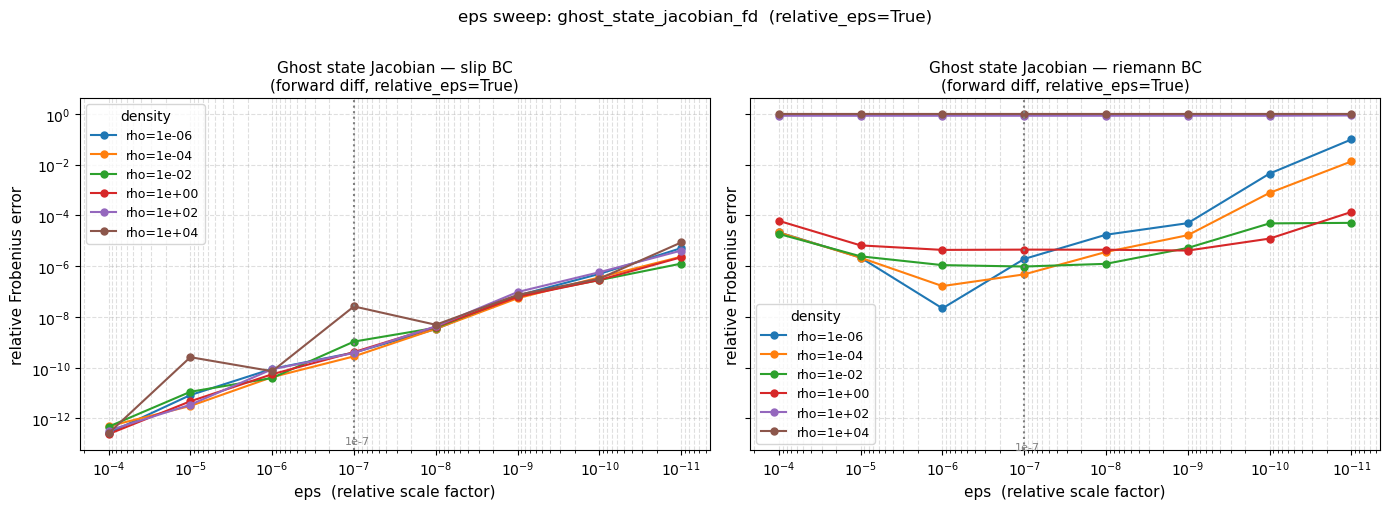

In [14]:
def prim_to_cons(rho, u, v, w, p, gamma=1.4):
    E = p / ((gamma - 1.0) * rho) + 0.5 * (u**2 + v**2 + w**2)
    return np.array([rho, rho*u, rho*v, rho*w, rho*E])

# ─────────────────────────────────────────────────────────────────────────────
# PART 1 — Updated ghost_state_jacobian_fd with relative eps + forward diff
# ─────────────────────────────────────────────────────────────────────────────
def ghost_state_jacobian_fd(U_i, bc_type, n,
                             gamma=1.4, R_gas=287.0,
                             u_b=0.0, v_b=0.0, w_b=0.0,
                             T_b=288.15, P_b=101325.0,
                             eps=1e-7,
                             relative_eps=True,
                             eps_abs=1e-14):
    """
    dU_ghost/dU_i  (5×5) via forward FD on ghost_state().

    relative_eps=True:
        h_k = eps * max(|U_i[k]|, eps_abs)
        scales with variable magnitude → consistent accuracy across
        rho ~ 1e-6 and rhoE ~ 1e4.
    relative_eps=False:
        h_k = eps  (fixed absolute step, old behaviour)
    """
    U_i = np.asarray(U_i, dtype=float)
    n   = np.asarray(n,   dtype=float)
    n   = n / np.linalg.norm(n)

    U_g_base = ghost_state(U_i, bc_type, n, gamma, R_gas,
                            u_b, v_b, w_b, T_b, P_b)   # F_base equivalent

    dUg = np.zeros((5, 5))

    for k in range(5):
        h = (eps * max(abs(U_i[k]), eps_abs)) if relative_eps else eps

        ej        = np.zeros(5);  ej[k] = h
        U_g_fwd   = ghost_state(U_i + ej, bc_type, n, gamma, R_gas,
                                 u_b, v_b, w_b, T_b, P_b)

        dUg[:, k] = (U_g_fwd - U_g_base) / h    # forward difference

    return dUg


# ─────────────────────────────────────────────────────────────────────────────
# PART 2 — Analytic reference Jacobians
#
# Slip:  U_ghost = [rho, rho*(v − 2*vn*n), rhoE]
#        In momentum: M_ghost = M − 2*(M·n)*n  (independent of rho!)
#        → dUg/dUi is exactly:
#            row/col 0 (rho):  identity
#            rows/cols 1-3:    I − 2*n*n^T  (momentum reflection)
#            row/col 4 (rhoE): identity
#
# Riemann: no compact analytic form → use central FD at eps=1e-10 as reference
# ─────────────────────────────────────────────────────────────────────────────
def ghost_state_jacobian_slip_analytic(n):
    """Exact dUg/dUi for slip BC — independent of U."""
    n   = np.asarray(n, dtype=float)
    n   = n / np.linalg.norm(n)
    dUg = np.zeros((5, 5))
    dUg[0, 0]    = 1.0                            # rho unchanged
    dUg[4, 4]    = 1.0                            # rhoE unchanged
    dUg[1:4, 1:4] = np.eye(3) - 2.0 * np.outer(n, n)   # reflect normal mom
    return dUg

def ghost_state_jacobian_riemann_ref(U_i, n,
                                      gamma=1.4, R_gas=287.0,
                                      u_b=0., v_b=0., w_b=0.,
                                      T_b=288.15, P_b=101325.,
                                      eps_ref=1e-10):
    """Central FD at very small eps — used as reference for Riemann BC."""
    dUg = np.zeros((5, 5))
    for k in range(5):
        ej = np.zeros(5);  ej[k] = eps_ref
        Ug_fwd = ghost_state(U_i + ej, 'riemann', n, gamma, R_gas,
                              u_b, v_b, w_b, T_b, P_b)
        Ug_bwd = ghost_state(U_i - ej, 'riemann', n, gamma, R_gas,
                              u_b, v_b, w_b, T_b, P_b)
        dUg[:, k] = (Ug_fwd - Ug_bwd) / (2 * eps_ref)
    return dUg


# ─────────────────────────────────────────────────────────────────────────────
# PART 3 — eps × rho sweep for both BC types
# ─────────────────────────────────────────────────────────────────────────────
eps_values = [10**(-e) for e in range(4, 12)]      # 1e-4 … 1e-11
rho_values = [1e-6, 1e-4, 1e-2, 1.0, 1e2, 1e4]

n_bc = np.array([1.0, 0.0, 0.0])
u_b, v_b, w_b, T_b, P_b = 68.0, 0.0, 0.0, 288.15, 1.32702

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

gamma = 1.4
R_gas = 287

for ax, bc_type in zip(axes, ['slip', 'riemann']):

    for rho in rho_values:
        U_i = prim_to_cons(rho, 50.0, 2.0, 0.0, 101325.0)

        # reference Jacobian
        if bc_type == 'slip':
            dUg_ref  = ghost_state_jacobian_slip_analytic(n_bc)
        else:
            dUg_ref  = ghost_state_jacobian_riemann_ref(
                U_i, n_bc, gamma=gamma, R_gas=R_gas,
                u_b=u_b, v_b=v_b, w_b=w_b, T_b=T_b, P_b=P_b)

        ref_norm = np.linalg.norm(dUg_ref) + 1e-20

        errors = []
        for eps in eps_values:
            dUg_fd = ghost_state_jacobian_fd(
                U_i, bc_type, n_bc,
                gamma=gamma, R_gas=R_gas,
                u_b=u_b, v_b=v_b, w_b=w_b, T_b=T_b, P_b=P_b,
                eps=eps, relative_eps=True)

            rel_err = np.linalg.norm(dUg_ref - dUg_fd) / ref_norm
            errors.append(rel_err)

        ax.plot(eps_values, errors, marker='o', markersize=5,
                label=f'rho={rho:.0e}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('eps  (relative scale factor)', fontsize=11)
    ax.set_ylabel('relative Frobenius error', fontsize=11)
    ax.set_title(f'Ghost state Jacobian — {bc_type} BC\n'
                  '(forward diff, relative_eps=True)', fontsize=11)
    ax.legend(title='density', fontsize=9)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.axvline(1e-7, color='grey', linestyle=':', linewidth=1.5)
    ax.text(1e-7 * 1.3, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-14,
            '1e-7', color='grey', fontsize=8)

plt.suptitle('eps sweep: ghost_state_jacobian_fd  (relative_eps=True)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()